In [43]:
from google.colab import files
uploaded= files.upload()

Saving sample_images_metadata.csv to sample_images_metadata.csv


In [44]:
import pandas as pd

df = pd.read_csv('sample_images_metadata.csv')
df.head()

,date,explanation,hdurl,media_type,service_version,title,url,copyright,local_filename
0,1995-06-16,Today's Picture: Explanation: If the Earth...,https://apod.nasa.gov/apod/image/e_lens.gif,image,v1,Neutron Star Earth,https://apod.nasa.gov/apod/image/e_lens.gif,NaN,1995-06-16.gif
1,1995-06-20,"Today's Picture: June 20, 1995 The Pleiades...",https://apod.nasa.gov/apod/image/pleiades2.gif,image,v1,Pleiades Star Cluster,https://apod.nasa.gov/apod/image/pleiades2.gif,NaN,1995-06-20.gif
2,1995-06-21,"Today's Picture: June 21, 1995 The Aftermat...",https://apod.nasa.gov/apod/image/sn1987a_hst.gif,image,v1,Supernova 1987a Aftermath,https://apod.nasa.gov/apod/image/sn1987a_hst.gif,NaN,1995-06-21.gif
3,1995-06-22,In 1972 Astronauts on the United States's last...,https://apod.nasa.gov/apod/image/earth_a17.gif,image,v1,Earth from Apollo 17,https://apod.nasa.gov/apod/image/earth_a17.gif,NaN,1995-06-22.gif
4,1995-06-23,"What if you could ""see"" gamma rays? This compu...",https://apod.nasa.gov/apod/image/egret_gro.gif,image,v1,Gamma Ray Sky Map,https://apod.nasa.gov/apod/image/egret_gro.gif,NaN,1995-06-23.gif


In [47]:
print(df.columns)

Index(['date', 'explanation', 'hdurl', 'media_type', 'service_version',
       'title', 'url', 'copyright', 'local_filename'],
      dtype='object')


In [48]:
import os
import requests
from tqdm import tqdm

os.makedirs('/content/images', exist_ok=True)

valid_indices = []

def download_image(url, path):
    try:
        r = requests.get(url, timeout=8)
        if r.status_code == 200:
            with open(path, 'wb') as f:
                f.write(r.content)
            return True
    except:
        return False
    return False

for i in tqdm(range(len(df))):
    url = df.iloc[i]['hdurl']   # 🔴 THIS IS THE FIX
    path = f'/content/images/{i}.jpg'

    if download_image(url, path):
        valid_indices.append(i)

print("Downloaded:", len(valid_indices))

100%|██████████| 100/100 [00:21<00:00,  4.60it/s]

Downloaded: 100


In [49]:
df_clean = df.iloc[valid_indices].reset_index(drop=True)

In [50]:
import shutil

clean_folder = '/content/images_clean'
os.makedirs(clean_folder, exist_ok=True)

for new_idx, old_idx in enumerate(valid_indices):
    old_path = f'/content/images/{old_idx}.jpg'
    new_path = f'{clean_folder}/{new_idx}.jpg'
    shutil.copy(old_path, new_path)

In [51]:
import os

print("Images:", len(os.listdir(clean_folder)))
print("Dataset:", len(df_clean))

Images: 1997
Dataset: 100


In [52]:
def label_data(title):
    title = title.lower()

    if 'galaxy' in title:
        return 0
    elif 'nebula' in title:
        return 1
    elif 'planet' in title or 'moon' in title:
        return 2
    else:
        return 3

df_clean['label'] = df_clean['title'].apply(label_data)

In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

In [54]:
class APODDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = f"{self.img_dir}/{idx}.jpg"
        image = Image.open(img_path).convert("RGB")
        label = self.df.iloc[idx]['label']

        if self.transform:
            image = self.transform(image)

        return image, label

In [55]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

In [56]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df_clean, test_size=0.2, random_state=42)

In [57]:
train_dataset = APODDataset(train_df, '/content/images_clean', transform)
val_dataset   = APODDataset(val_df, '/content/images_clean', transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

In [58]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 4)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 4)

model = model.to(device)

In [60]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 5.2591
Epoch 2, Loss: 5.3014
Epoch 3, Loss: 5.4126
Epoch 4, Loss: 5.2117
Epoch 5, Loss: 5.3624


In [61]:
epochs = 30

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 5.1629
Epoch 2, Loss: 5.1260
Epoch 3, Loss: 5.2093
Epoch 4, Loss: 5.3642
Epoch 5, Loss: 5.3305
Epoch 6, Loss: 5.2870
Epoch 7, Loss: 5.4661
Epoch 8, Loss: 5.1957
Epoch 9, Loss: 5.2253
Epoch 10, Loss: 5.3473
Epoch 11, Loss: 5.3123
Epoch 12, Loss: 5.2574
Epoch 13, Loss: 5.2434
Epoch 14, Loss: 5.2502
Epoch 15, Loss: 4.9917
Epoch 16, Loss: 5.1872
Epoch 17, Loss: 5.1943
Epoch 18, Loss: 5.3193
Epoch 19, Loss: 5.3146
Epoch 20, Loss: 5.1357
Epoch 21, Loss: 5.4651
Epoch 22, Loss: 5.2893
Epoch 23, Loss: 5.1234
Epoch 24, Loss: 5.2409
Epoch 25, Loss: 5.1843
Epoch 26, Loss: 5.2580
Epoch 27, Loss: 5.2794
Epoch 28, Loss: 5.0402
Epoch 29, Loss: 5.1181
Epoch 30, Loss: 5.1575


In [62]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

accuracy = 100 * correct / total
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 30.00%


In [63]:
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [64]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.00      0.00      0.00         0
           2       0.25      0.80      0.38         5
           3       0.00      0.00      0.00        13

    accuracy                           0.25        20
   macro avg       0.15      0.33      0.20        20
weighted avg       0.10      0.25      0.14        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

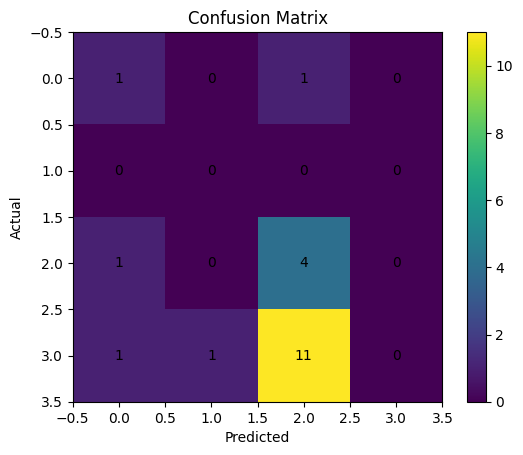

In [65]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds, average='weighted'))
print("Recall:", recall_score(all_labels, all_preds, average='weighted'))
print("F1 Score:", f1_score(all_labels, all_preds, average='weighted'))

Accuracy: 0.25
Precision: 0.09583333333333333
Recall: 0.25
F1 Score: 0.13523809523809524


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [67]:
losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    losses.append(running_loss)
    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 5.1696
Epoch 2, Loss: 5.3318
Epoch 3, Loss: 5.2061
Epoch 4, Loss: 5.2776
Epoch 5, Loss: 5.4029
Epoch 6, Loss: 5.3031
Epoch 7, Loss: 5.1469
Epoch 8, Loss: 5.2955
Epoch 9, Loss: 5.2871
Epoch 10, Loss: 5.1373
Epoch 11, Loss: 5.0929
Epoch 12, Loss: 5.0740
Epoch 13, Loss: 5.2175
Epoch 14, Loss: 5.3345
Epoch 15, Loss: 5.2170
Epoch 16, Loss: 5.0559
Epoch 17, Loss: 5.3830
Epoch 18, Loss: 5.3133
Epoch 19, Loss: 5.2687
Epoch 20, Loss: 5.0818
Epoch 21, Loss: 5.2915
Epoch 22, Loss: 5.2528
Epoch 23, Loss: 5.3178
Epoch 24, Loss: 5.3226
Epoch 25, Loss: 5.1588
Epoch 26, Loss: 5.2315
Epoch 27, Loss: 5.2778
Epoch 28, Loss: 5.3325
Epoch 29, Loss: 5.3914
Epoch 30, Loss: 5.1460


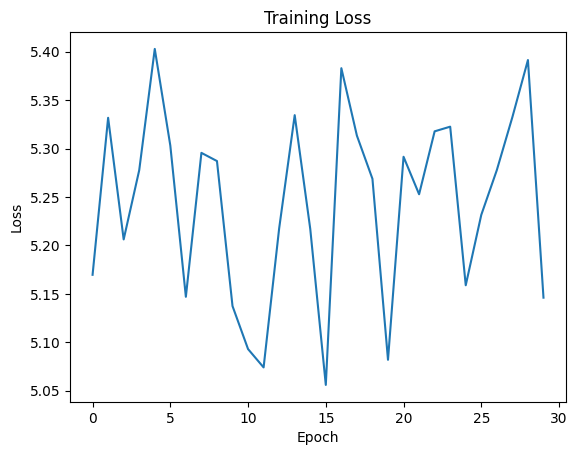

In [68]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

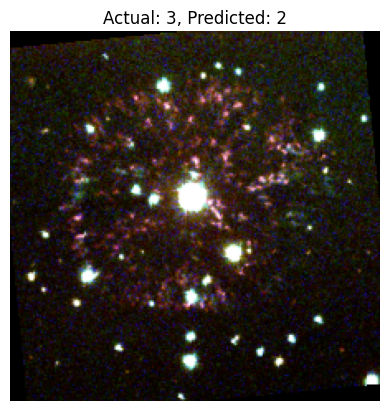

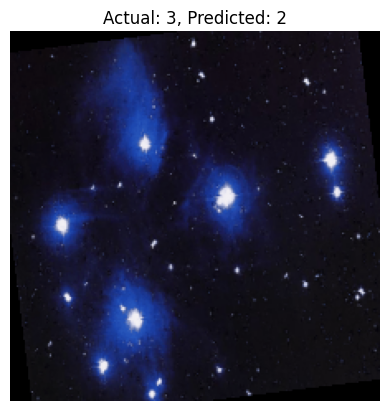

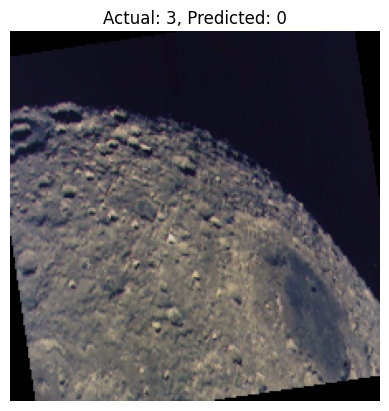

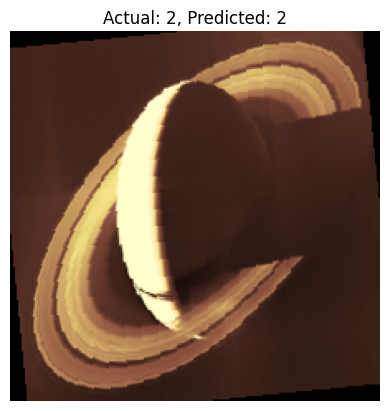

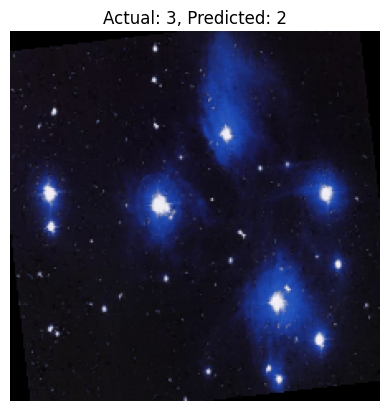

In [69]:
import random

model.eval()

for i in range(5):
    idx = random.randint(0, len(val_dataset)-1)
    img, label = val_dataset[idx]

    with torch.no_grad():
        output = model(img.unsqueeze(0).to(device))
        _, pred = torch.max(output, 1)

    plt.imshow(img.permute(1,2,0))
    plt.title(f"Actual: {label}, Predicted: {pred.item()}")
    plt.axis('off')
    plt.show()